In [ ]:
#Aluno: Gustavo Alcides Lorensi

# Introdução

Os dados foram obtidos da Global Energy Monitor, [link](https://globalenergymonitor.org/projects/global-nuclear-power-tracker/), atualizados até setembro de 2025. Esta base é um conjunto de dados real que monitora unidades de energia nuclear em todo o mundo, detalhando sua capacidade, status de operação e tecnologia utilizadas nos reatores .


# Dados e Primeiro Tratamento

Ao todo são **1749 dados** de diversos reatores e países. Com 18 variáveis que utilizaremos, sendo elas:

    'Country/Area' = Pais
    'Project Name' = Nome do Projeto
    'Unit Name' = Número/Nome da Unidade
    'Capacity (MW)' = Capacidade de produção atual
    'Status' = Situação
    'Reactor Type'= Tipo de Reator
    'Model' = Modelo
    'Start Year' = Ano de inicio de funcionamento comercial
    'Retirement Year' = Ano de aposentadoria
    'Planned Retirement' = Data planejada de aposentadoria
    'Cancellation Year' = Data de cancelamento do projeto
    'Construction Start Date' = Data inicio construção
    'First Criticality Date' = Data primeira criticalidade (auto-sustentavel)
    'Retirement Date' = Data de aposentadoria
    'Reference Net Capacity (MW)' = Capacidade capacidade de operação
    'Design Net Capacity (MW)' = Capacidade projetada
    'Subregion' = Subregiao Global
    'Region' = Regiao Global
  


Primeiramente será necessário limpar algumas colunas da database, visto que não serão utilizadas ao longo desse estudo. Aproveitamos para definir algumas variaveis e extrair alguns dados que serão necessários para uma melhor análise.




---
# Código que limpa e arruma tudo:

In [ ]:
# @title
import pandas
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

dados = pandas.read_excel('Global-Nuclear-Power-Tracker-September-2025.xlsx', sheet_name='Data')

#Se quiser ver tabela, liberar aqui:
#dados.head()

#lista de colunas importantes
colunas_selecionadas = [
    'Country/Area',
    'Project Name',
    'Unit Name',
    'Capacity (MW)',
    'Status',
    'Reactor Type',
    'Model',
    'Start Year',
    'Retirement Year',
    'Planned Retirement',
    'Cancellation Year',
    'Construction Start Date',
    'First Criticality Date',
    'Retirement Date',
    'Reference Net Capacity (MW)',
    'Design Net Capacity (MW)',
    'Subregion',
    'Region'
]

#realizando mapeamento para limpar a tabela
mapeamento_status = {
    'announced': 'announced',
    'pre-construction': 'announced', #pre construindo = anunciado
    'construction': 'construction',
    'operating': 'operating',
    'shelved': 'cancelled', # parado = cancelado
    'shelved - inferred 2 y': 'cancelled',  # parado = cancelado
    'cancelled': 'cancelled',
    'cancelled - inferred 4 y': 'cancelled',
    'mothballed': 'retired', # desativa, caso queiram ativar no futuro = retired
    'retired': 'retired'
}


#so pra listar os headers
#print(dados.columns.tolist())

#limpar colunas
dados_limpos = dados[colunas_selecionadas].copy()

#limpar status
dados_limpos['Status'] = dados_limpos['Status'].map(mapeamento_status)

#  .astype(str) para botar tudo como texto e juntar tudo
dados_limpos['Unit Name'] = dados_limpos['Project Name'].astype(str) + " - " + dados_limpos['Unit Name'].astype(str)

dados_limpos = dados_limpos.drop(columns=['Project Name'])


# Convertendo as colunas para o formato de data (datetime)
dados_limpos['Construction Start Date'] = pandas.to_datetime(dados_limpos['Construction Start Date'], errors='coerce')
dados_limpos['First Criticality Date'] = pandas.to_datetime(dados_limpos['First Criticality Date'], errors='coerce')
dados_limpos['Retirement Date'] = pandas.to_datetime(dados_limpos['Retirement Date'], errors='coerce')

# Criando colunas de cálculo de anos
dados_limpos['Lifespan_Years'] = dados_limpos['Retirement Year'] - dados_limpos['Start Year']
dados_limpos['Decade'] = (dados_limpos['Start Year'] // 10) * 10

In [ ]:
#mostrar dados::::::
#dados_limpos

# Classificação das Variáveis

*   Country/Area - Qualitativa Nominal
*   Project Name - Qualitativa Nominal
*   Unit Name	-	Qualitativa Nominal
*   Capacity (MW)	-	Quantitativa Contínua
*   Status - Qualitativa Nominal
*   Reactor Type - Qualitativa Nominal
*   Model	-	Qualitativa Nominal
*   Start Year - Quantitativa Discreta
*   Retirement Year	-	Quantitativa Discreta
*   Planned Retirement - Qualitativa Ordinal (ou Data)
*   Cancellation Year	-	Quantitativa Discreta
*   Construction Start Date	- Qualitativa Ordinal (ou Data)
*   First Criticality Date - Qualitativa Ordinal (ou Data)
*   Retirement Date	-	Qualitativa Ordinal (ou Data)
*   Reference Net Capacity (MW)	-	Quantitativa Contínua
*   Design Net Capacity (MW) - Quantitativa Contínua
*   Subregion	-	Qualitativa Nominal
*   Region - Qualitativa Nominal

---



# Contexto

A construção de uma usina nuclear envolve várias fases. Aqui resumiremos em quatro estágios, Announced, Construction, Operating, Retired.

Dada a complexidade do projeto, cada fase demora anos para ser finalizada e cada projeto é único. Usando como base o arquivo de dados que obtivemos, vamos tentar extrair algumas informações sobre o andamento de projetos, projetos já concluídos, histórico de países e o futuro da energia nuclear no mundo.

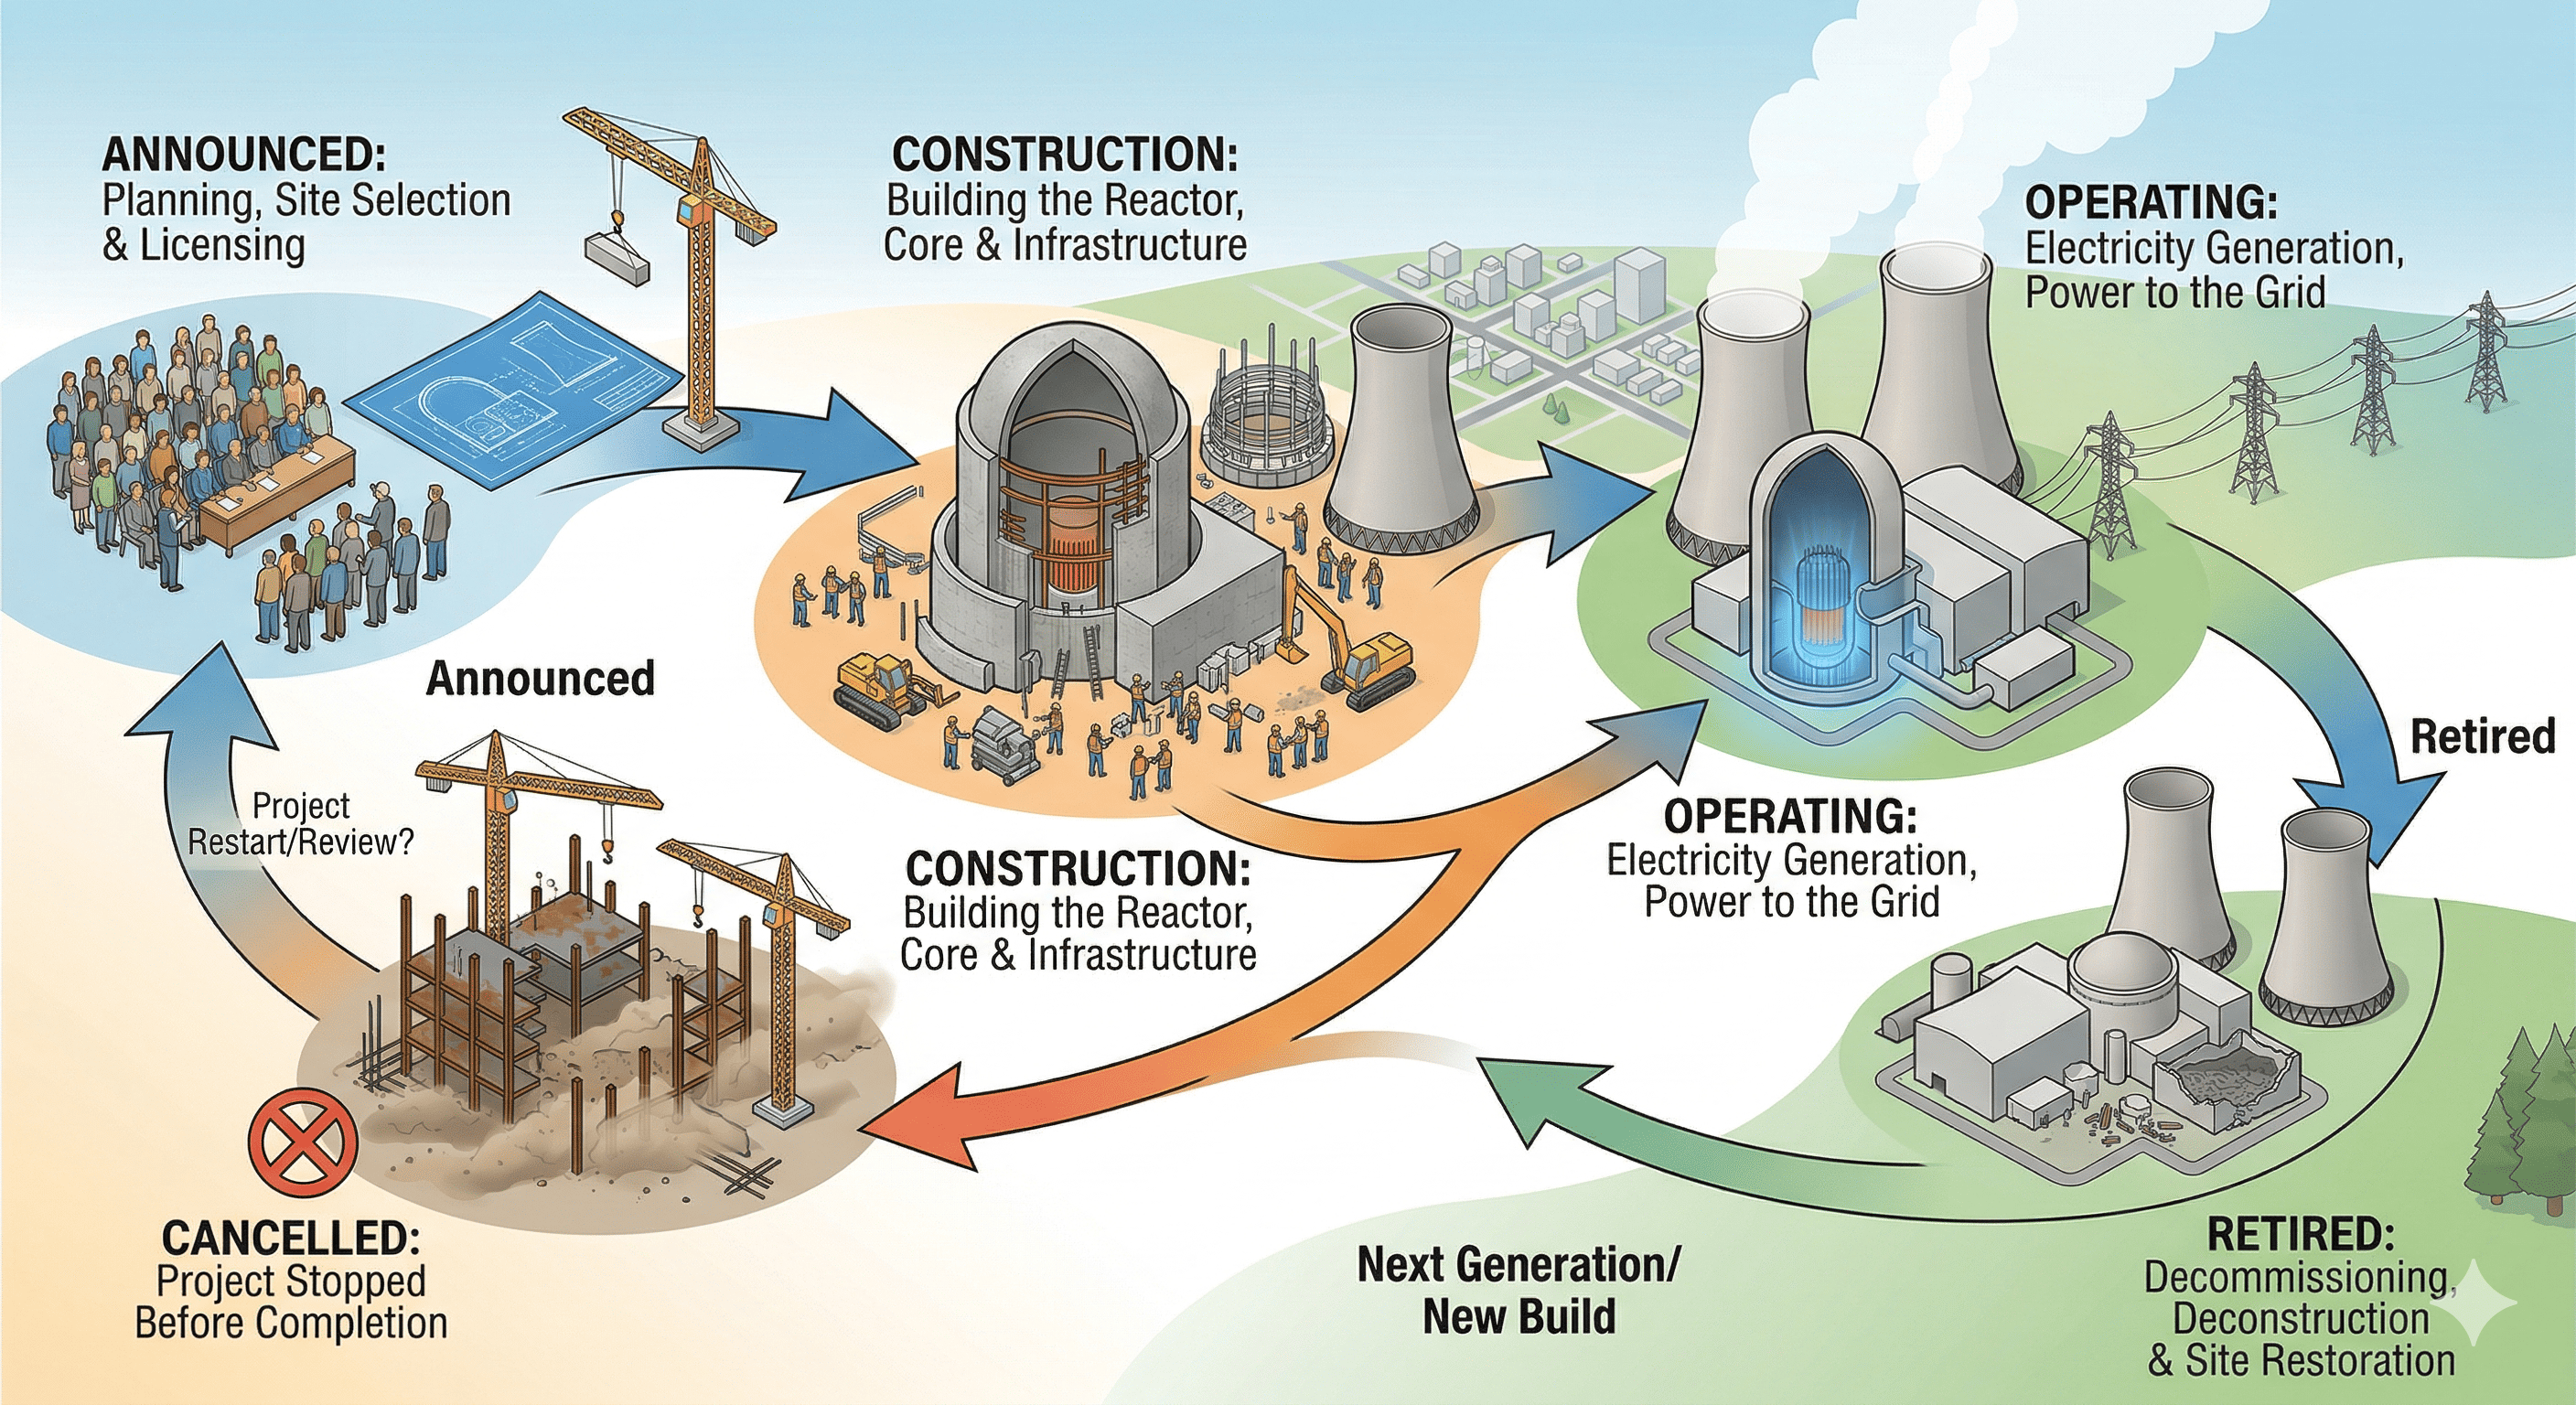

# Análise dos Dados



Observe abaixo que grande parte dos projetos são cancelados, cerca de 570 projetos. Outros 430 foram anunciados, e 76 estão em construção. Já 421 reatores estão em funcionamento e outros 252 estão aposentados.

--- Contagem de Reatores por Status ---
Status
cancelled       570
announced       430
operating       421
retired         252
construction     76
Name: count, dtype: int64

--- Distribuição Percentual ---
Status
cancelled       32.590051
announced       24.585477
operating       24.070898
retired         14.408233
construction     4.345340
Name: proportion, dtype: float64


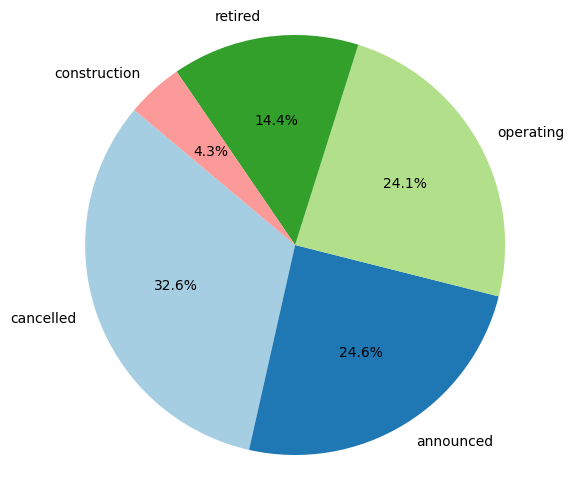

In [ ]:
# @title
# Contagem de reatores por status
contagem_status = dados_limpos['Status'].value_counts()

print("--- Contagem de Reatores por Status ---")
print(contagem_status)

print("\n--- Distribuição Percentual ---")
print(dados_limpos['Status'].value_counts(normalize=True) * 100)

plt.figure(figsize=(7, 6)) # Ajusta o tamanho da imagem
plt.pie(
    contagem_status,
    labels=contagem_status.index,
    autopct='%1.1f%%',  # Mostra a porcentagem com uma casa decimal
    startangle=140,     # Rotaciona o gráfico para melhor visualização
    colors=plt.cm.Paired.colors, # Usa uma paleta de cores variada
)
plt.axis('equal') # Garante que o gráfico seja um círculo perfeito
plt.show()

**Pergunta:** Mas quanto tempo demora para construir um reator?

- Primeiro, filtramos a média de tempo entre a data de construção até a data de criticalidade. Ou seja, estamos olhando quanto tempo demorou para funcionar. Observe que o tempo média está em 6.96 anos.

- Contudo, agora filtramos pelos 5 reatores que foram construidos mais rapidamente. Observe que os 5 mais rapidos, os quais foram construidos em menos de 3 anos (menor sendo 1 ano), tem uma baixa capacidade de produção, de menos de 100MW.
- Ao analisar os 5 mais demorados, observamos que os quatro primeiros demoraram mais de 30 anos. Sendo 3 dos 5 com produção superior a 1000 MW.

- Aplicando outro filtro é possivel ver que 425 reatores tiveram tempo de construção entre 5 e 30 anos, com média de 8 anos.

In [ ]:
# @title
print("------")
# Tempo entre Construção e Criticalidade (anos)
dados_limpos['Anos_Construcao'] = (dados_limpos['First Criticality Date'] - dados_limpos['Construction Start Date']).dt.days / 365.25
mais_rapidas = dados_limpos.nsmallest(5, 'Anos_Construcao')[['Country/Area','Reactor Type','Capacity (MW)', 'Anos_Construcao']]
mais_demoradas = dados_limpos.nlargest(5, 'Anos_Construcao')[['Country/Area','Reactor Type','Capacity (MW)', 'Anos_Construcao']]
print(f"\n--- Média de tempo (Construção até Criticalidade): {dados_limpos['Anos_Construcao'].mean():.2f} anos ---")


print("--- As 5 construções mais rápidas ---")
print(mais_rapidas)
print("\n--- As 5 construções mais demoradas ---")
print(mais_demoradas)

filtro_intervalo = (dados_limpos['Anos_Construcao'] >= 5) & (dados_limpos['Anos_Construcao'] <= 30)
dados_filtrados = dados_limpos[filtro_intervalo]
media_filtrada = dados_filtrados['Anos_Construcao'].mean()
print("------")
print(f"--- Média Filtrada (5 a 30 anos): {media_filtrada:.2f} anos ---")
print(f"Total de reatores no intervalo: {len(dados_filtrados)}")

------

--- Média de tempo (Construção até Criticalidade): 6.96 anos ---
--- As 5 construções mais rápidas ---
       Country/Area               Reactor Type  Capacity (MW)  Anos_Construcao
1577  United States                    unknown           12.0         1.002053
1631  United States  pressurized water reactor            2.0         1.508556
1706  United States      boiling water reactor           24.0         1.587953
1477  United States      boiling water reactor           65.0         2.291581
1362  United States      boiling water reactor           71.0         2.406571

--- As 5 construções mais demoradas ---
       Country/Area                     Reactor Type  Capacity (MW)  \
1722  United States        pressurized water reactor         1218.0   
702            Iran        pressurized water reactor         1000.0   
1062       Slovakia        pressurized water reactor          471.0   
1         Argentina  pressurized heavy water reactor          745.0   
1022         Russia

**Pergunta:** E quanto a vida útil de um reator?

- Filtrando por pelo tempo de vida de reatores em operação temos média de 55 anos e os já aposentados, perto dos 30 anos de atividade. Por que isso ocorre? O principal fator é a evolução tecnologica entre gerações de reatores. observe o próximo item

In [ ]:
# @title
# Vida Operacional (Retirement - Criticality)
dados_limpos['Anos_Operacao'] = (dados_limpos['Retirement Date'] - dados_limpos['First Criticality Date']).dt.days / 365.25

media_op = dados_limpos[dados_limpos['Status'] == 'operating']['Anos_Operacao'].mean()
print(f"--- Média de Vida Operacional (Status = Operating): {media_op:.2f} anos ---")

media_ret = dados_limpos[dados_limpos['Status'] == 'retired']['Anos_Operacao'].mean()
print(f"--- Média de Vida Operacional (Status = Retired): {media_ret:.2f} anos ---")

--- Média de Vida Operacional (Status = Operating): 55.67 anos ---
--- Média de Vida Operacional (Status = Retired): 30.08 anos ---


**Pergunta:** Observe a lista dos top 10 reatores com mais tempo de vida:

- Note que 80% destes são do modelo/tipo, CANDU. CANDU = CANada Deuterium Uranium, um tipo de reator desenvolvido pelo Canada. Tal modelo é de "fácil" instalação e não necessita de Uranio Enriquecido.

In [ ]:
# @title

# Top 10 maiores diferenças (Lifespan)
print("--- Top 10 Maiores Ciclos de Vida (Anos) ---")
display(dados_limpos.nlargest(10, 'Lifespan_Years')[['Unit Name', 'Lifespan_Years', 'Model', 'Capacity (MW)']])

--- Top 10 Maiores Ciclos de Vida (Anos) ---


,Unit Name,Lifespan_Years,Model,Capacity (MW)
48,Bruce nuclear power plant - A3,86.0,CANDU 750A,865.0
49,Bruce nuclear power plant - A4,85.0,CANDU 750A,868.0
51,Bruce nuclear power plant - B6,80.0,CANDU 750B,891.0
50,Bruce nuclear power plant - B5,79.0,CANDU 750B,872.0
52,Bruce nuclear power plant - B7,78.0,CANDU 750B,872.0
53,Bruce nuclear power plant - B8,77.0,CANDU 750B,872.0
470,Loviisa nuclear power plant - 1,73.0,VVER V-213,531.0
471,Loviisa nuclear power plant - 2,69.0,VVER V-213,531.0
47,Bruce nuclear power plant - A2,66.0,CANDU 791,836.0
46,Bruce nuclear power plant - A1,65.0,CANDU 791,868.0


**Pergunta:** Falando em tipos de reatores. Qual é o modelo mais comum?

- Como podemos ver no gráfico abaixo, o modelo mais comum é o Pressurized Water Reactor (PWR), o qual é um modelo antigo e muito popular.

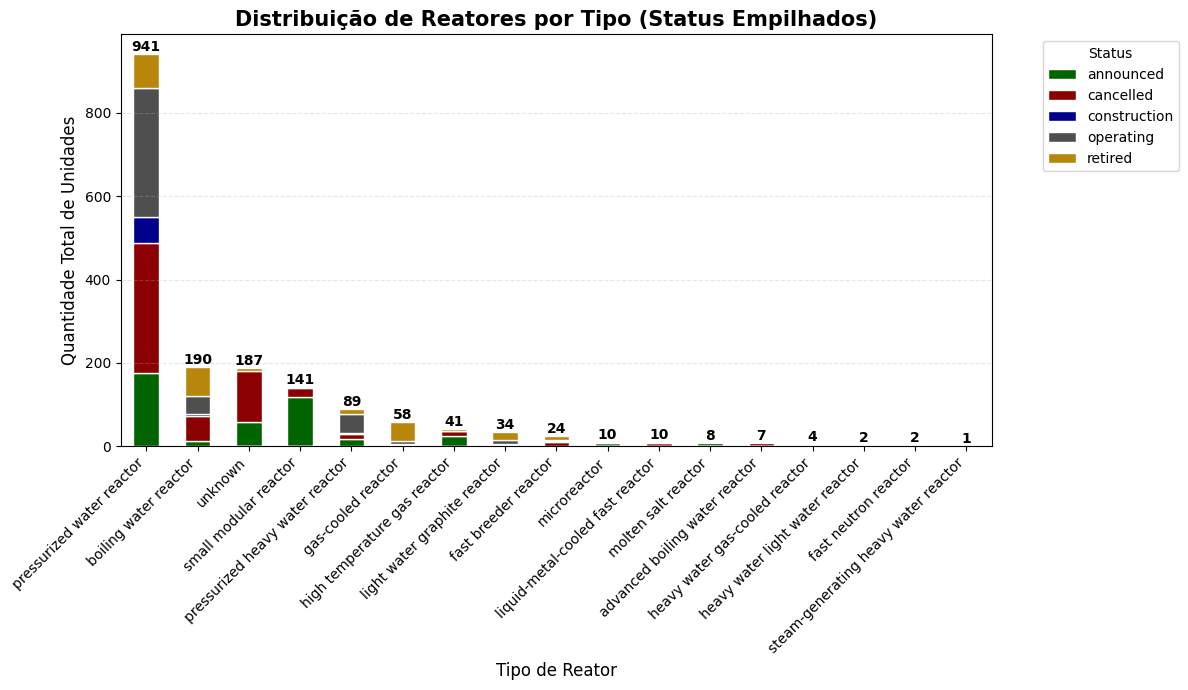

In [ ]:
# @title
# Gráfico de Barras: Total de Reatores por Tipo
ordem_tipos = dados_limpos['Reactor Type'].value_counts().index
tabela_cruzada = pandas.crosstab(dados_limpos['Reactor Type'], dados_limpos['Status']).reindex(ordem_tipos)

# Definir uma paleta de cores clara para os status
cores_mapa = {
    'announced': '#006400',
    'cancelled': '#8B0000',
    'construction': '#00008B',
    'operating': '#4F4F4F',
    'retired': '#B8860B'
}
# Criar uma lista de cores na ordem das colunas da tabela_cruzada
cores_lista = [cores_mapa.get(col, '#333333') for col in tabela_cruzada.columns]

# 3. Gerar o gráfico empilhado (stacked=True)
ax = tabela_cruzada.plot(kind='bar', stacked=True, figsize=(12, 7), color=cores_lista, edgecolor='white')

# 4. Adicionar os totais no topo de cada barra empilhada
totais = tabela_cruzada.sum(axis=1)
for i, valor in enumerate(totais):
    ax.text(i, valor + 0.5, f'{int(valor)}', ha='center', va='bottom', fontweight='bold')

# 5. Ajustes finais de layout
plt.title('Distribuição de Reatores por Tipo (Status Empilhados)', fontsize=15, fontweight='bold')
plt.xlabel('Tipo de Reator', fontsize=12)
plt.ylabel('Quantidade Total de Unidades', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Pergunta:** Existe uma tendencia de reatores de acordo com a década?

- Podemos dizer que sim, Boling Water Reactors (BWR) foram muito populares no inicio da "corrida nuclear". Como podemos ver na tabela abaixo, BWR foram construidos principalmente na decada de 60, 70 e 80. Após os anos 80, Pressurized Water Reactor (PWR) se tornou mais polular dado sua eficiencia e elevada segurança (Muitooo mais que o BWR).

- Note também, que os reatores do tipo Pressurized Heavy Water Reactor (PHWR) sempre foram construidos ao longo da década. O que é ótimo, pois é muito seguro e não utiliza uranio enriquecido.

In [ ]:
# @title
dados_construidos = dados_limpos[dados_limpos['Status'].str.lower().isin(['operating', 'retired'])]

# Gera a tabela cruzada
print("\n--- Tipos de Reatores Concluídos (Ativos + Aposentados) por Década ---")
reatores_decada_construidos = pandas.crosstab(dados_construidos['Decade'], dados_construidos['Reactor Type'])
display(reatores_decada_construidos)


--- Tipos de Reatores Concluídos (Ativos + Aposentados) por Década ---


Reactor Type,boiling water reactor,fast breeder reactor,gas-cooled reactor,heavy water gas-cooled reactor,heavy water light water reactor,high temperature gas reactor,light water graphite reactor,pressurized heavy water reactor,pressurized water reactor,steam-generating heavy water reactor,unknown
Decade,,,,,,,,,,,
1950.0,1,0,8,0,0,0,3,0,2,0,3
1960.0,18,2,25,2,0,2,5,5,15,1,3
1970.0,43,4,9,2,2,1,10,11,78,0,0
1980.0,35,2,11,0,0,1,10,15,155,0,0
1990.0,9,1,0,0,0,0,1,12,28,0,0
2000.0,4,0,0,0,0,0,0,8,26,0,0
2010.0,0,1,0,0,0,0,0,4,56,0,0
2020.0,2,0,0,0,0,1,0,3,28,0,0


Falando em uranio enriquecido, tenha em mente que uranio enriquecido = bombas nucleares!

**Pergunta:** Vamos analisar as listas abaixo, que mostram a realçao entre o numero de reatores X paises para diferentes Status.  

- Observe que os EUA assumem o topo da lista de anuncios de reatores nucleares, 92 todo, seguido pela China com 76 e Polandia com 49. Já dizia o ditado "falar é fácil, difícil é fazer". Quando analisamos os paises que tem mais reatores em construção, temos a China com 33 reatores, o segundo lugar já mais distante com apenas 7, ocupado pela Russia, seguido da India com 6. EUA aparece na oitava colocaçao, com somente 3 reatores.

- Analisando os que estão em funcionamento, temos em primeiro EUA, com 94 reatores, seguido pela China com 58 e França com 57. Tratando dos aposentados, temos EUA em primeiro com 47 reatores aposentados, Japão com 44 e Alemanha com 37.

- Portanto, ao comparar as duas maiores potencias, EUA e China, temos dois extremos. De um lado, EUA que no século passado apostou fortemente na produção de energia nuclear, e construi inumeros reatores. Mas que não vem repondo o numero de reatores aposentados. Do outro temos a China, que aposta na construção de reatores para suprir sua alta demanda energetica.

In [ ]:
# @title
# Top 10 Países por Status
for status_alvo in ['announced', 'construction', 'operating', 'retired']:
    print(f"\n--- Top 10 Country/Area com status '{status_alvo}' ---")
    print(dados_limpos[dados_limpos['Status'] == status_alvo]['Country/Area'].value_counts().head(10))




--- Top 10 Country/Area com status 'announced' ---
Country/Area
United States     92
China             76
Poland            49
Russia            36
India             24
Uganda            16
Ghana             13
United Kingdom    12
Canada            11
Kazakhstan         8
Name: count, dtype: int64

--- Top 10 Country/Area com status 'construction' ---
Country/Area
China             33
Russia             7
India              6
Japan              5
Egypt              4
South Korea        4
Türkiye            4
United States      3
United Kingdom     2
Bangladesh         2
Name: count, dtype: int64

--- Top 10 Country/Area com status 'operating' ---
Country/Area
United States     94
China             58
France            57
Russia            36
South Korea       26
India             21
Canada            19
Ukraine           15
Japan             14
United Kingdom     9
Name: count, dtype: int64

--- Top 10 Country/Area com status 'retired' ---
Country/Area
United States     47
Japan     

**Pergunta:** Quanto a aposentadoria, quais são os proximos reatores que vão ser aposentados?

- Analisando a lista abaixo, temos 2 reatores dos EUA em 2030. O proximo da lista será na Armenia, ainda em 2026.

In [ ]:
# @title
# Pegando o ano atual
ano_atual = datetime.now().year

# Filtrando usinas onde o ano de aposentadoria é maior ou igual ao ano atual
# E garantindo que o valor não seja nulo
proximos_anos = dados_limpos[dados_limpos['Retirement Year'] >= ano_atual].dropna(subset=['Retirement Year'])

print(f"\n--- Próximas 10 Unidades a serem Aposentadas (Baseado no Ano) ---")
# nsmallest(10) pega os 10 anos mais próximos do atual
display(proximos_anos.nsmallest(10, 'Retirement Year')[['Unit Name', 'Retirement Year', 'Status', 'Country/Area']])


--- Próximas 10 Unidades a serem Aposentadas (Baseado no Ano) ---


,Unit Name,Retirement Year,Status,Country/Area
10,Armenian nuclear power plant - 2,2026.0,operating,Armenia
1418,Diablo Canyon nuclear power plant - 1,2030.0,operating,United States
1419,Diablo Canyon nuclear power plant - 2,2030.0,operating,United States
1009,Novovoronezh nuclear power plant - 1-4,2032.0,operating,Russia
828,Borssele nuclear power plant - 1,2033.0,operating,Netherlands
1220,South Ukraine nuclear power plant - 1,2033.0,operating,Ukraine
1033,Smolensk nuclear power plant - 1-1,2034.0,operating,Russia
1034,Smolensk nuclear power plant - 1-2,2034.0,operating,Russia
1035,Smolensk nuclear power plant - 1-3,2034.0,operating,Russia
25,Doel nuclear power plant - 4,2035.0,operating,Belgium


# E o Brasil?

- Conforme podemos observar abaixo. O brasil tem 2 reatores em operação, e 1 em construção. Os reatores em funcionamento começaram a serem construidos em 1971 e 1976, mas só atingiram criticalidade em 1982 e 2000. Ou seja, para o pior dos casos, aproximadamente 24 anos de construção até a efetiva geração.
O terceiro reator nuclear está em fase de construção, iniciada em 2010.

In [ ]:
reatores_brasil = dados_limpos[dados_limpos['Country/Area'] == 'Brazil']
colunas_interesse = ['Unit Name', 'Reactor Type', 'Status', 'Construction Start Date', 'First Criticality Date']
reatores_brasil[colunas_interesse]

,Unit Name,Reactor Type,Status,Construction Start Date,First Criticality Date
29,Angra nuclear power plant - 1,pressurized water reactor,operating,1971-05-01,1982-03-13
30,Angra nuclear power plant - 2,pressurized water reactor,operating,1976-01-01,2000-07-14
31,Angra nuclear power plant - 3,pressurized water reactor,construction,2010-05-30,NaT


---
Probabilidade
---



**Pergunta:** Qual a probabilidade de um reator escolhido ao acaso estar na Ásia? e reator em construção ser na Ásia.


- A chance de 36% do reator estar na Ásia, mas isso engloba todas as situações, incluindo cancelados. Ao analisar apenas em construção, temos 76% de chance do reator ser na Ásia. Ou seja, o maior número de reatores em construção é na Ásia.

**Pergunta:** Qual a probabilidade de um reator ser do tipo PWR?

- A chance de ser PWR é de 53%, mostrando que PWR realmente é o queridinho de todos.


In [ ]:
# @title
total_reatores = len(dados_limpos)
reatores_asia = len(dados_limpos[dados_limpos['Region'] == 'Asia'])
prob_asia = (reatores_asia / total_reatores) * 100

print(f"Probabilidade de um reator aleatório ser na Ásia: {prob_asia:.2f}%")

#ver pegar o status contrction e depois pegar a regiao
em_construcao = dados_limpos[dados_limpos['Status'] == 'construction']
asia_construcao = len(em_construcao[em_construcao['Region'] == 'Asia'])
prob_condicional = (asia_construcao / len(em_construcao)) * 100

print(f"Probabilidade de um reator em construção ser na Ásia: {prob_condicional:.2f}%")


quantidade_pwr = len(dados_limpos[dados_limpos['Reactor Type'] == 'pressurized water reactor'])

#chance de ser pwr
probabilidade_pwr = (quantidade_pwr / total_reatores) * 100
print(f"A probabilidade de um reator escolhido ao acaso ser do tipo PWR é de: {probabilidade_pwr:.2f}%")

Probabilidade de um reator aleatório ser na Ásia: 36.82%
Probabilidade de um reator em construção ser na Ásia: 76.32%
A probabilidade de um reator escolhido ao acaso ser do tipo PWR é de: 53.80%


**Pergunta:** A capadidade dos reatores segue uma Distribuição Normal?

- Observamos que a capacidade dos reatores não segue uma distribuição normal... Interessante notar que temos uma concentração de reatores com menos de 120 MW de potencia e na faixa de 1000 MW - 1400 MW. O primeiro se deve ao fato de que existe uma grande quantidade de reatores experimentais, de baixa potencia. O segundo range se deve ao fato de que estes sao, efetivamente, reatores para produção de energia em larga escala.

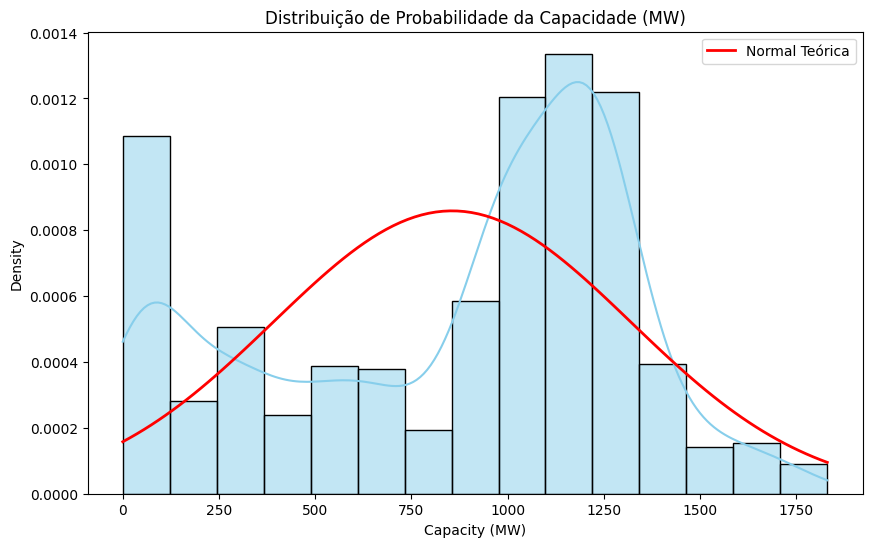

In [ ]:
# @title
import scipy.stats as stats

# gráfico
plt.figure(figsize=(10, 6))
sns.histplot(dados_limpos['Capacity (MW)'], kde=True, stat="density", color='skyblue')

# colocando curva normal teorica
mu, std = dados_limpos['Capacity (MW)'].mean(), dados_limpos['Capacity (MW)'].std()
x = np.linspace(dados_limpos['Capacity (MW)'].min(), dados_limpos['Capacity (MW)'].max(), 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'r', linewidth=2, label='Normal Teórica')

plt.title('Distribuição de Probabilidade da Capacidade (MW)')
plt.legend()
plt.show()

**Pergunta:** Qual a distribuição da quantidade de inícios de construção d reatores por ano?

- Temos uma Distribuição Geométrica. Notemos que existem alguns anos atípicos, onde tivemos mais de 30 reatores sendo iniciada a construção. Mas em cerca de 32 anos, 5 reatores começaram a serem construidos.


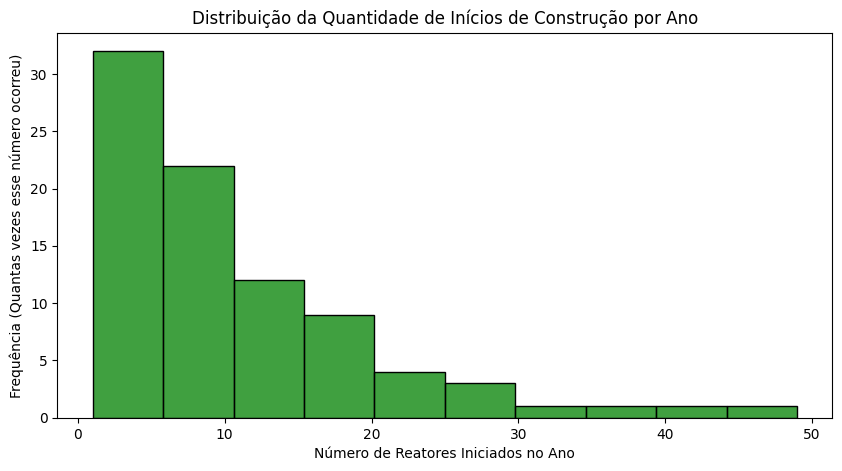

In [ ]:
# @title
# Contando quantos reatores iniciaram construção por ano
contagem_por_ano = dados_limpos['Start Year'].value_counts()

# Plotando para ver se lembra uma Poisson
plt.figure(figsize=(10,5))
sns.histplot(contagem_por_ano, kde=False, color='green')
plt.title('Distribuição da Quantidade de Inícios de Construção por Ano')
plt.xlabel('Número de Reatores Iniciados no Ano')
plt.ylabel('Frequência (Quantas vezes esse número ocorreu)')
plt.show()